## Synthetic Item Bank Visualization

This notebook builds a synthetic item bank for two latent traits and produces three visualizations:

1. **Discrimination hyperplanes** â€” each item's decision boundary drawn as a chord through the unit circle; sensitive item lines are thicker (proportional to `sensitivity_level`).
2. **Angle histogram** â€” sanity-check that directions are spread approximately evenly over `[0Â°, 180Â°)`.
3. **Threshold locations** â€” all sensitive items (sorted by level) plus one non-sensitive reference, showing where each item partitions the projected score axis.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np

repo_root = Path(r"C:\Users\49160\Adaptive-Onboarding")
sys.path.append(str(repo_root))

from src.synthetic import item_bank_to_dataframe, synthetic_item_bank
from src.plots import (
    apply_notebook_style, PALETTE,
    style_ax, format_axes,
    draw_question_arrow,
)

# Reusable global style for all notebook figures (fast, non-LaTeX rendering).
# Set use_tex=True only when you explicitly need full LaTeX text rendering.
apply_notebook_style()

print(f"Using repo root: {repo_root}")

Using repo root: C:\Users\49160\Adaptive-Onboarding


### Build a 2D Item Bank

In [2]:
bank = synthetic_item_bank(
    n_items=24,
    dim=2,
    n_categories=4,
    sensitive_fraction=0.30,
    rng_seed=1,
    vary_sensitivity_levels=True,
    angle_jitter=0.10,
    threshold_perturbation=0.08,
)

item_df = item_bank_to_dataframe(bank)
n_sensitive = int(item_df["is_sensitive"].sum())
print(f"Generated {len(item_df)} items: {n_sensitive} sensitive, {len(item_df) - n_sensitive} non-sensitive")
item_df[["item_id", "is_sensitive", "sensitivity_level", "angle", "a_0", "a_1"]].head()

Generated 24 items: 7 sensitive, 17 non-sensitive


,item_id,is_sensitive,sensitivity_level,angle,a_0,a_1
0,item_0000,False,0.000000,0.000155,1.000000,0.000155
1,item_0001,True,0.646442,0.136796,0.990658,0.136370
2,item_0002,False,0.000000,0.257141,0.967121,0.254317
3,item_0003,False,0.000000,0.398572,0.921616,0.388103
4,item_0004,False,0.000000,0.521136,0.867254,0.497865


### Discrimination Hyperplanes

Each line is the decision boundary (hyperplane) orthogonal to an item's discrimination vector `a`. Because all 2D directions live in the upper semicircle `[0, Ï€)`, the perpendicular hyperplanes cover the full circle. Sensitive item lines are thicker, with thickness proportional to `sensitivity_level`.

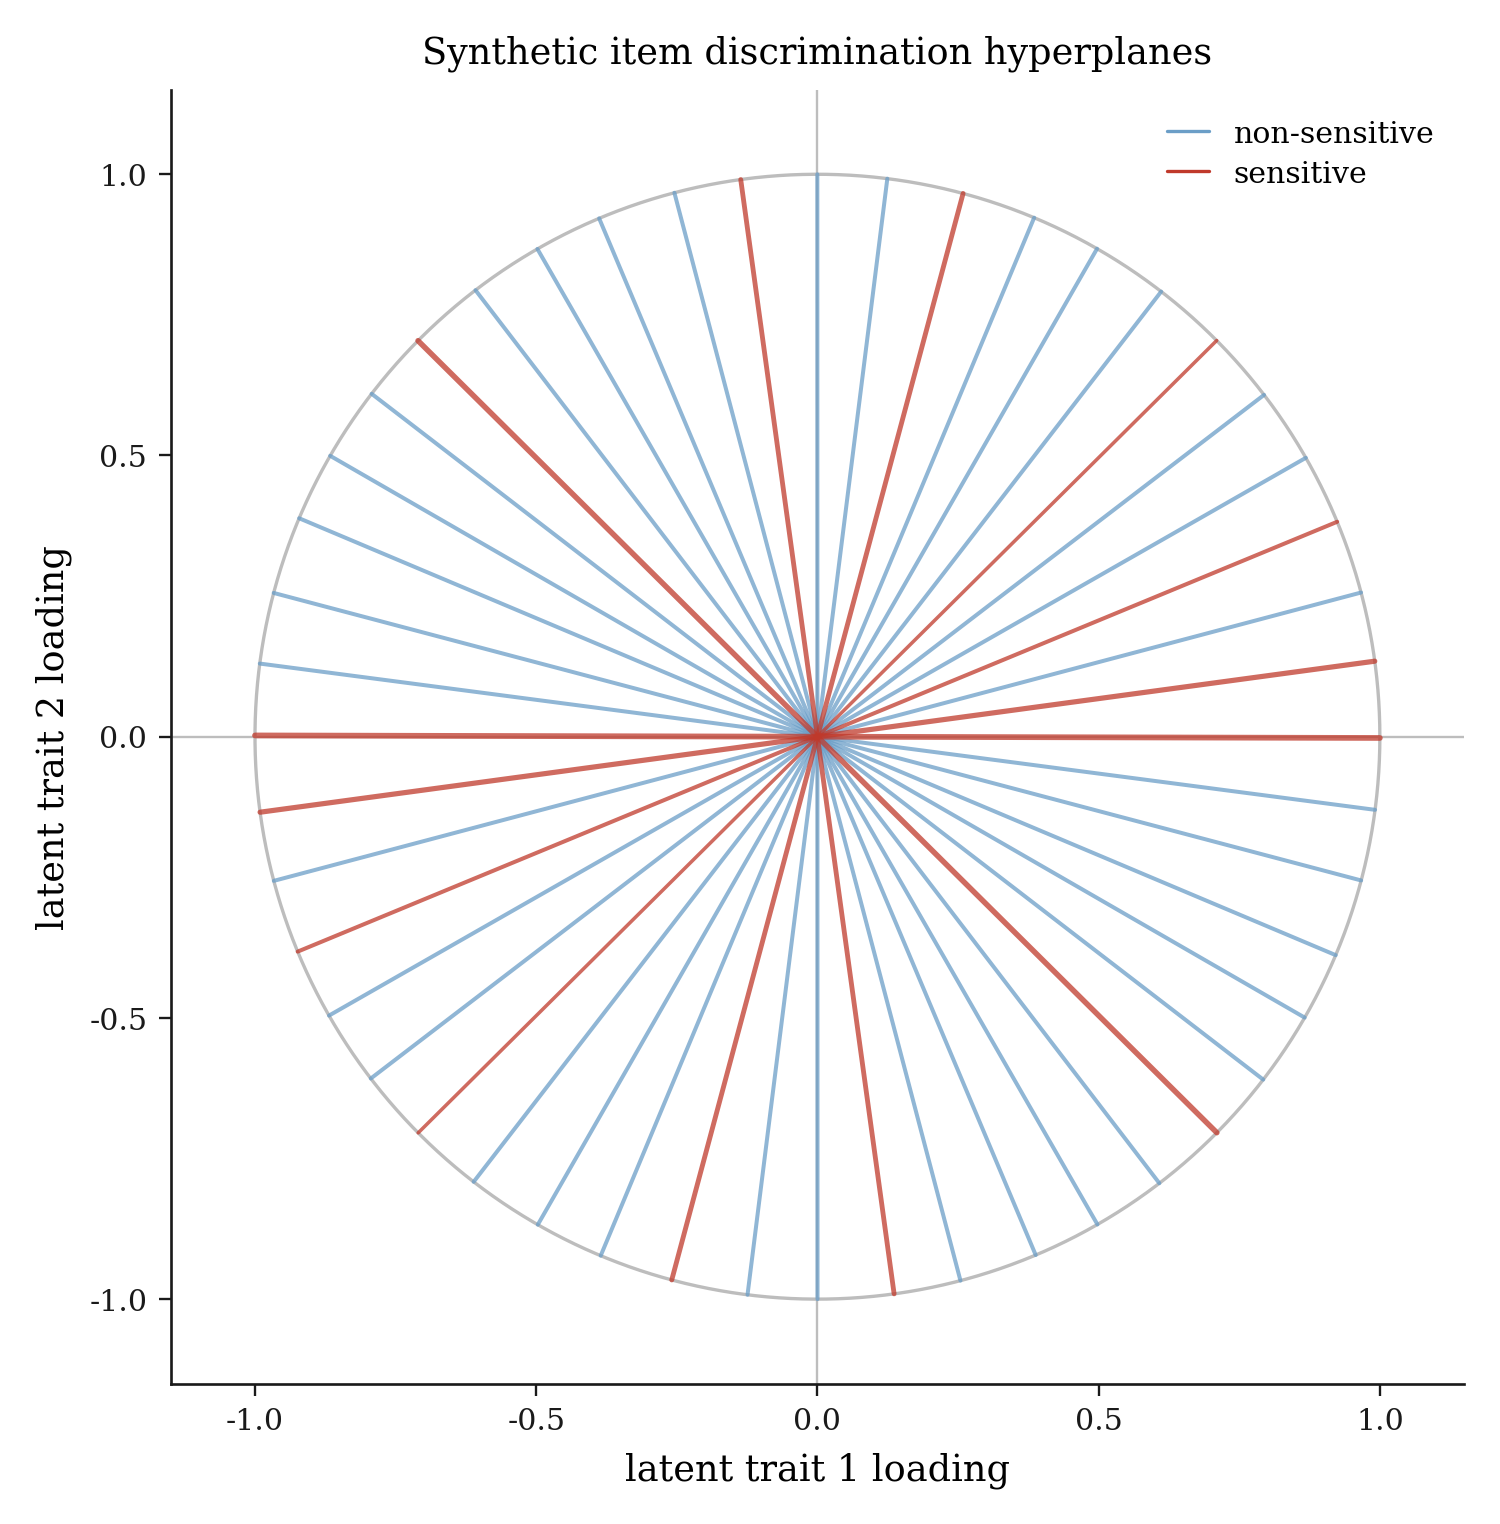

In [4]:
colors = {False: PALETTE["blue"], True: PALETTE["red"]}
labels = {False: "non-sensitive", True: "sensitive"}

fig, ax = plt.subplots(figsize=(7, 7))

theta = np.linspace(0, 2 * np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), color=PALETTE["rule"], linewidth=1)

for is_sensitive in [False, True]:
    selected = [item for item in bank if item.is_sensitive is is_sensitive]
    for item in selected:
        a = item.a
        perp = np.array([-a[1], a[0]])  # unit vector perpendicular to a
        lw = 0.8 + 1.0 * item.sensitivity_level if item.is_sensitive else 1.2
        ax.plot(
            [-perp[0], perp[0]],
            [-perp[1], perp[1]],
            color=colors[is_sensitive],
            alpha=0.75,
            linewidth=lw,
            solid_capstyle="round",
        )
    ax.plot([], [], color=colors[is_sensitive], label=labels[is_sensitive], linewidth=1)

ax.axhline(0, color=PALETTE["rule"], linewidth=0.7, zorder=0)
ax.axvline(0, color=PALETTE["rule"], linewidth=0.7, zorder=0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-1.15, 1.15)
ax.set_ylim(-1.15, 1.15)
ax.set_xlabel("latent trait 1 loading")
ax.set_ylabel("latent trait 2 loading")
ax.set_title("Synthetic item discrimination hyperplanes")
ax.legend(frameon=False)
plt.show()

### Distribution of Discrimination Angles

A quick sanity check that the generator spreads angles approximately evenly over `[0Â°, 180Â°)`.

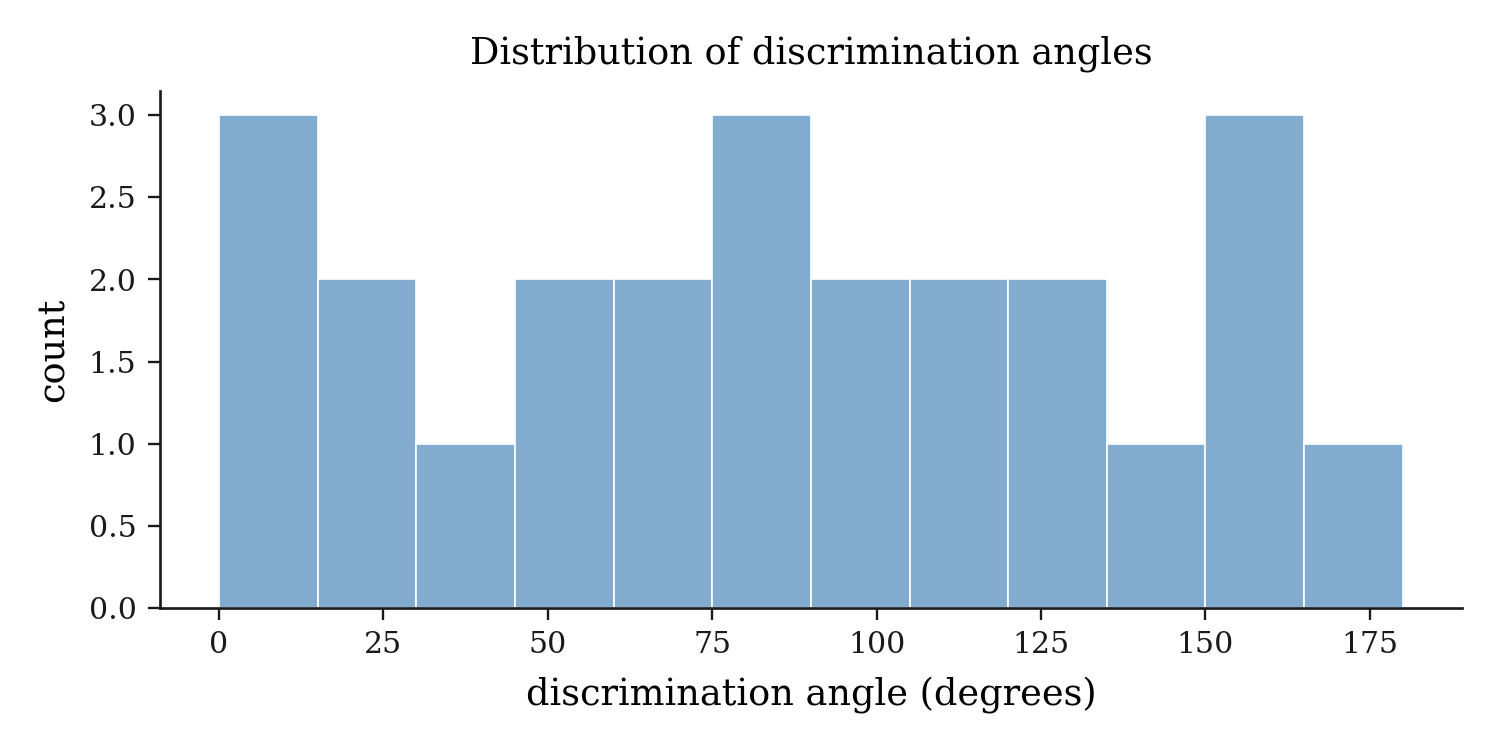

In [5]:
fig, ax = plt.subplots(figsize=(7, 2.8))

angles_deg = np.degrees(item_df["angle"].values)
ax.hist(
    angles_deg,
    bins=12,
    range=(0, 180),
    color=PALETTE["blue"],
    edgecolor="white",
    alpha=0.85,
)
ax.set_xlabel("discrimination angle (degrees)")
ax.set_ylabel("count")
ax.set_title("Distribution of discrimination angles")
style_ax(ax)
plt.show()

### One Item in Latent Coordinate Space

For one selected item, this plot shows:

- the discrimination vector `a` (arrow from the origin),
- the threshold-induced hyperplanes `a^T Î¸ = b_k` (parallel lines),
- and the corresponding normal directions.

This is the same geometry as the threshold view, but now shown directly in the latent coordinate system `(Î¸_1, Î¸_2)`.

AttributeError: 'NoneType' object has no attribute 'set_title'

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


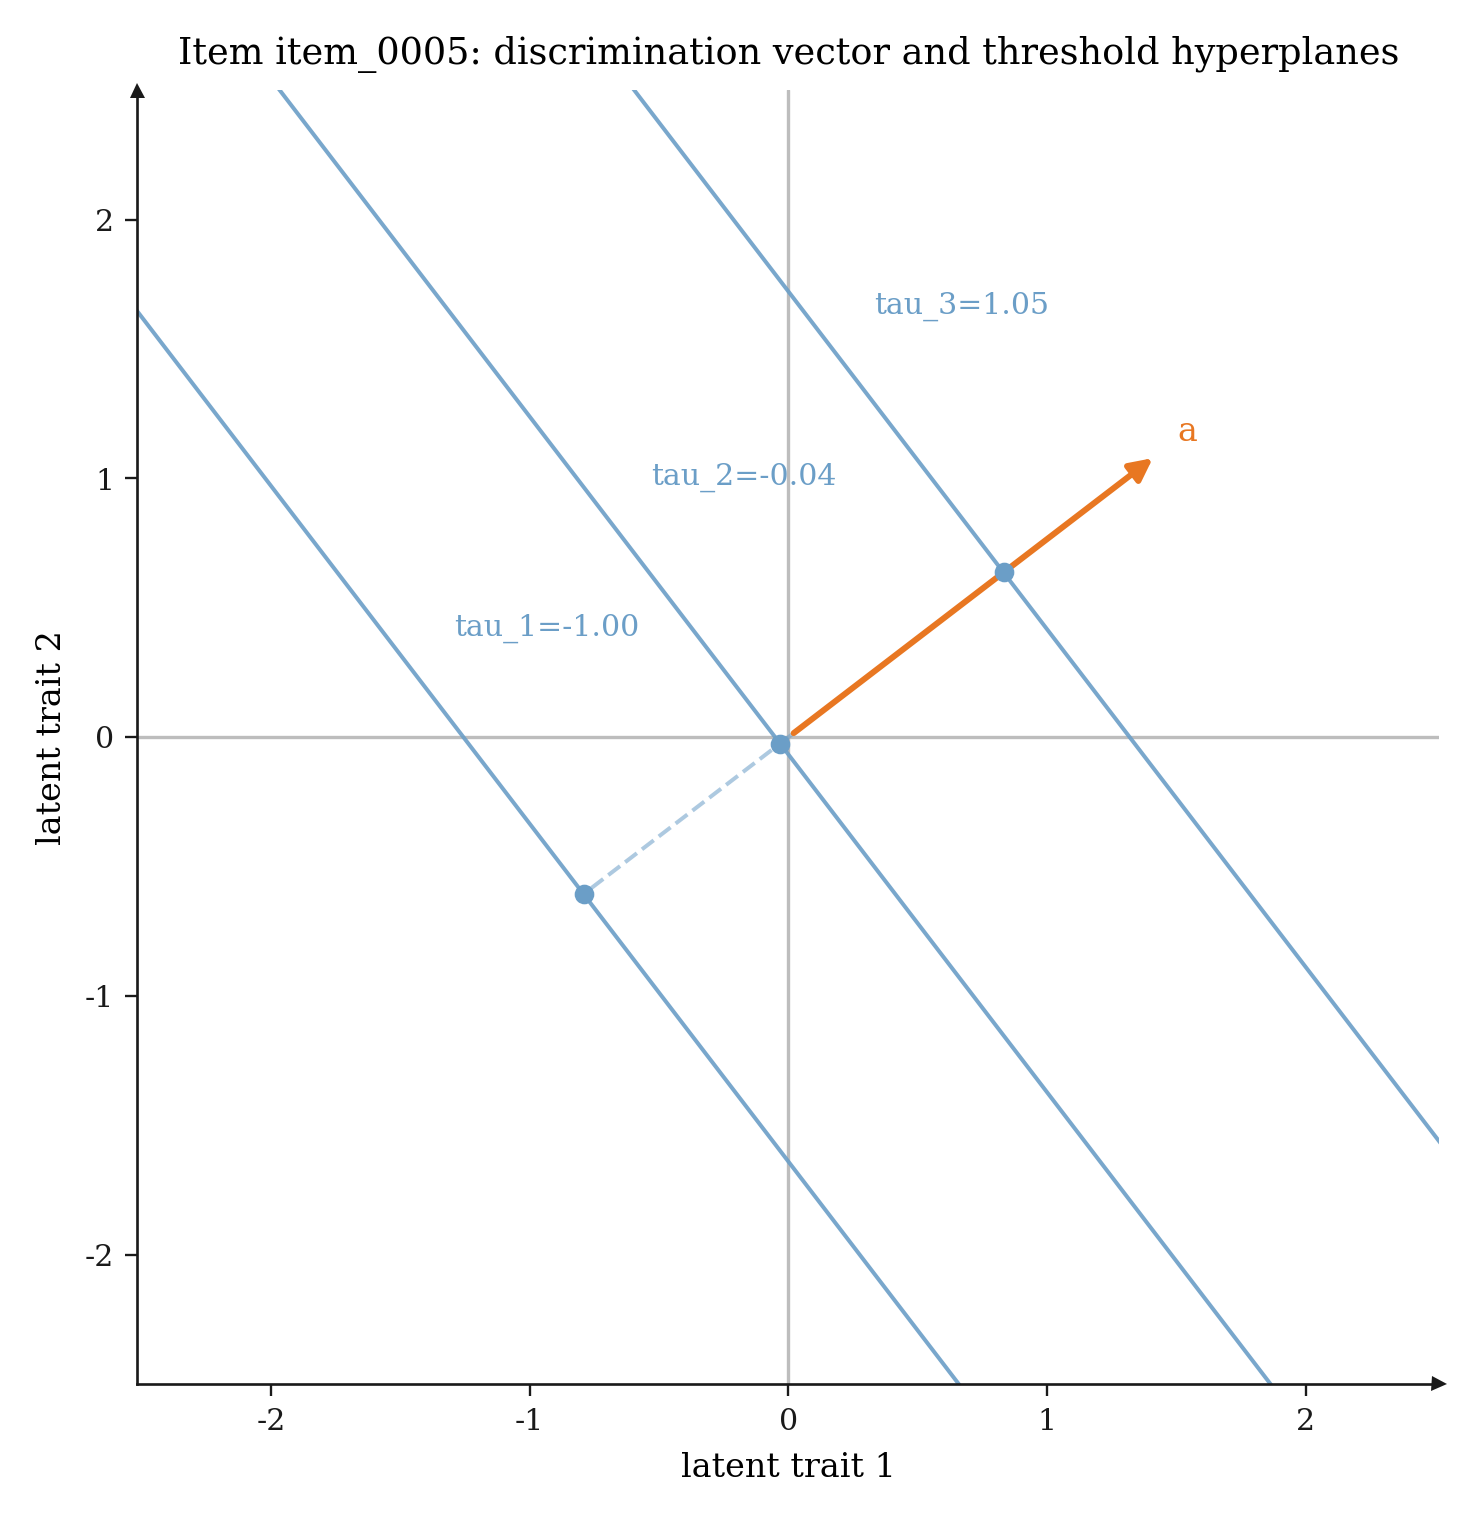

In [7]:
# Pick one item to visualize in latent coordinate space.
# Change this index to inspect another item's geometry.
item_index = 5
item = bank[item_index]

a = item.a.astype(float)
thresholds = item.thresholds.astype(float)
color = colors[item.is_sensitive]

# Unit normal vector for the hyperplanes and unit tangent direction along each line.
a_hat = a / np.linalg.norm(a)
t_hat = np.array([-a_hat[1], a_hat[0]])

# Plot extent in latent trait coordinates.
extent = 2.5
line_half_length = 4.0

fig, ax = plt.subplots(figsize=(7, 7))

# Draw coordinate axes.
ax.axhline(0.0, color=PALETTE["rule"], linewidth=1.0, zorder=0)
ax.axvline(0.0, color=PALETTE["rule"], linewidth=1.0, zorder=0)

# Draw the discrimination vector a from the origin.
draw_question_arrow(ax, origin=[0.0, 0.0], a=a_hat, scale=1.8, label="a")

# Draw threshold hyperplanes: a^T theta = b_k.
for k, b in enumerate(thresholds):
    center = b * a_hat
    p1 = center - line_half_length * t_hat
    p2 = center + line_half_length * t_hat
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color=color, linewidth=1.2, alpha=0.9)

    # Also draw a short normal segment to emphasize the offset along a.
    ax.plot([0.0, center[0]], [0.0, center[1]], color=color, linewidth=1.2, alpha=0.55, linestyle="--")
    ax.scatter([center[0]], [center[1]], color=color, s=28, zorder=5)
    ax.text(center[0]-0.5, center[1] + 1, f"tau_{k+1}={b:.2f}", color=color, fontsize=9)

ax.set_title(f"Item {item.item_id}: discrimination vector and threshold hyperplanes")
legend_label = f"{labels[item.is_sensitive]}, sensitivity={item.sensitivity_level:.2f}"
ax.plot([], [], color=color, linewidth=2.2, label="threshold hyperplanes")
ax.plot([], [], color=PALETTE["amber"], linewidth=2.0, label="discrimination direction a")
format_axes(ax, xlabel="latent trait 1", ylabel="latent trait 2",
            xlim=(-extent, extent), ylim=(-extent, extent))
ax.legend(loc="upper left", title=legend_label)
plt.show()

### Threshold Locations

The thresholds partition the projected score `a^T Î¸` into ordinal response categories. All items are shown in their original generation order (`item_0000`, `item_0001`, ...).

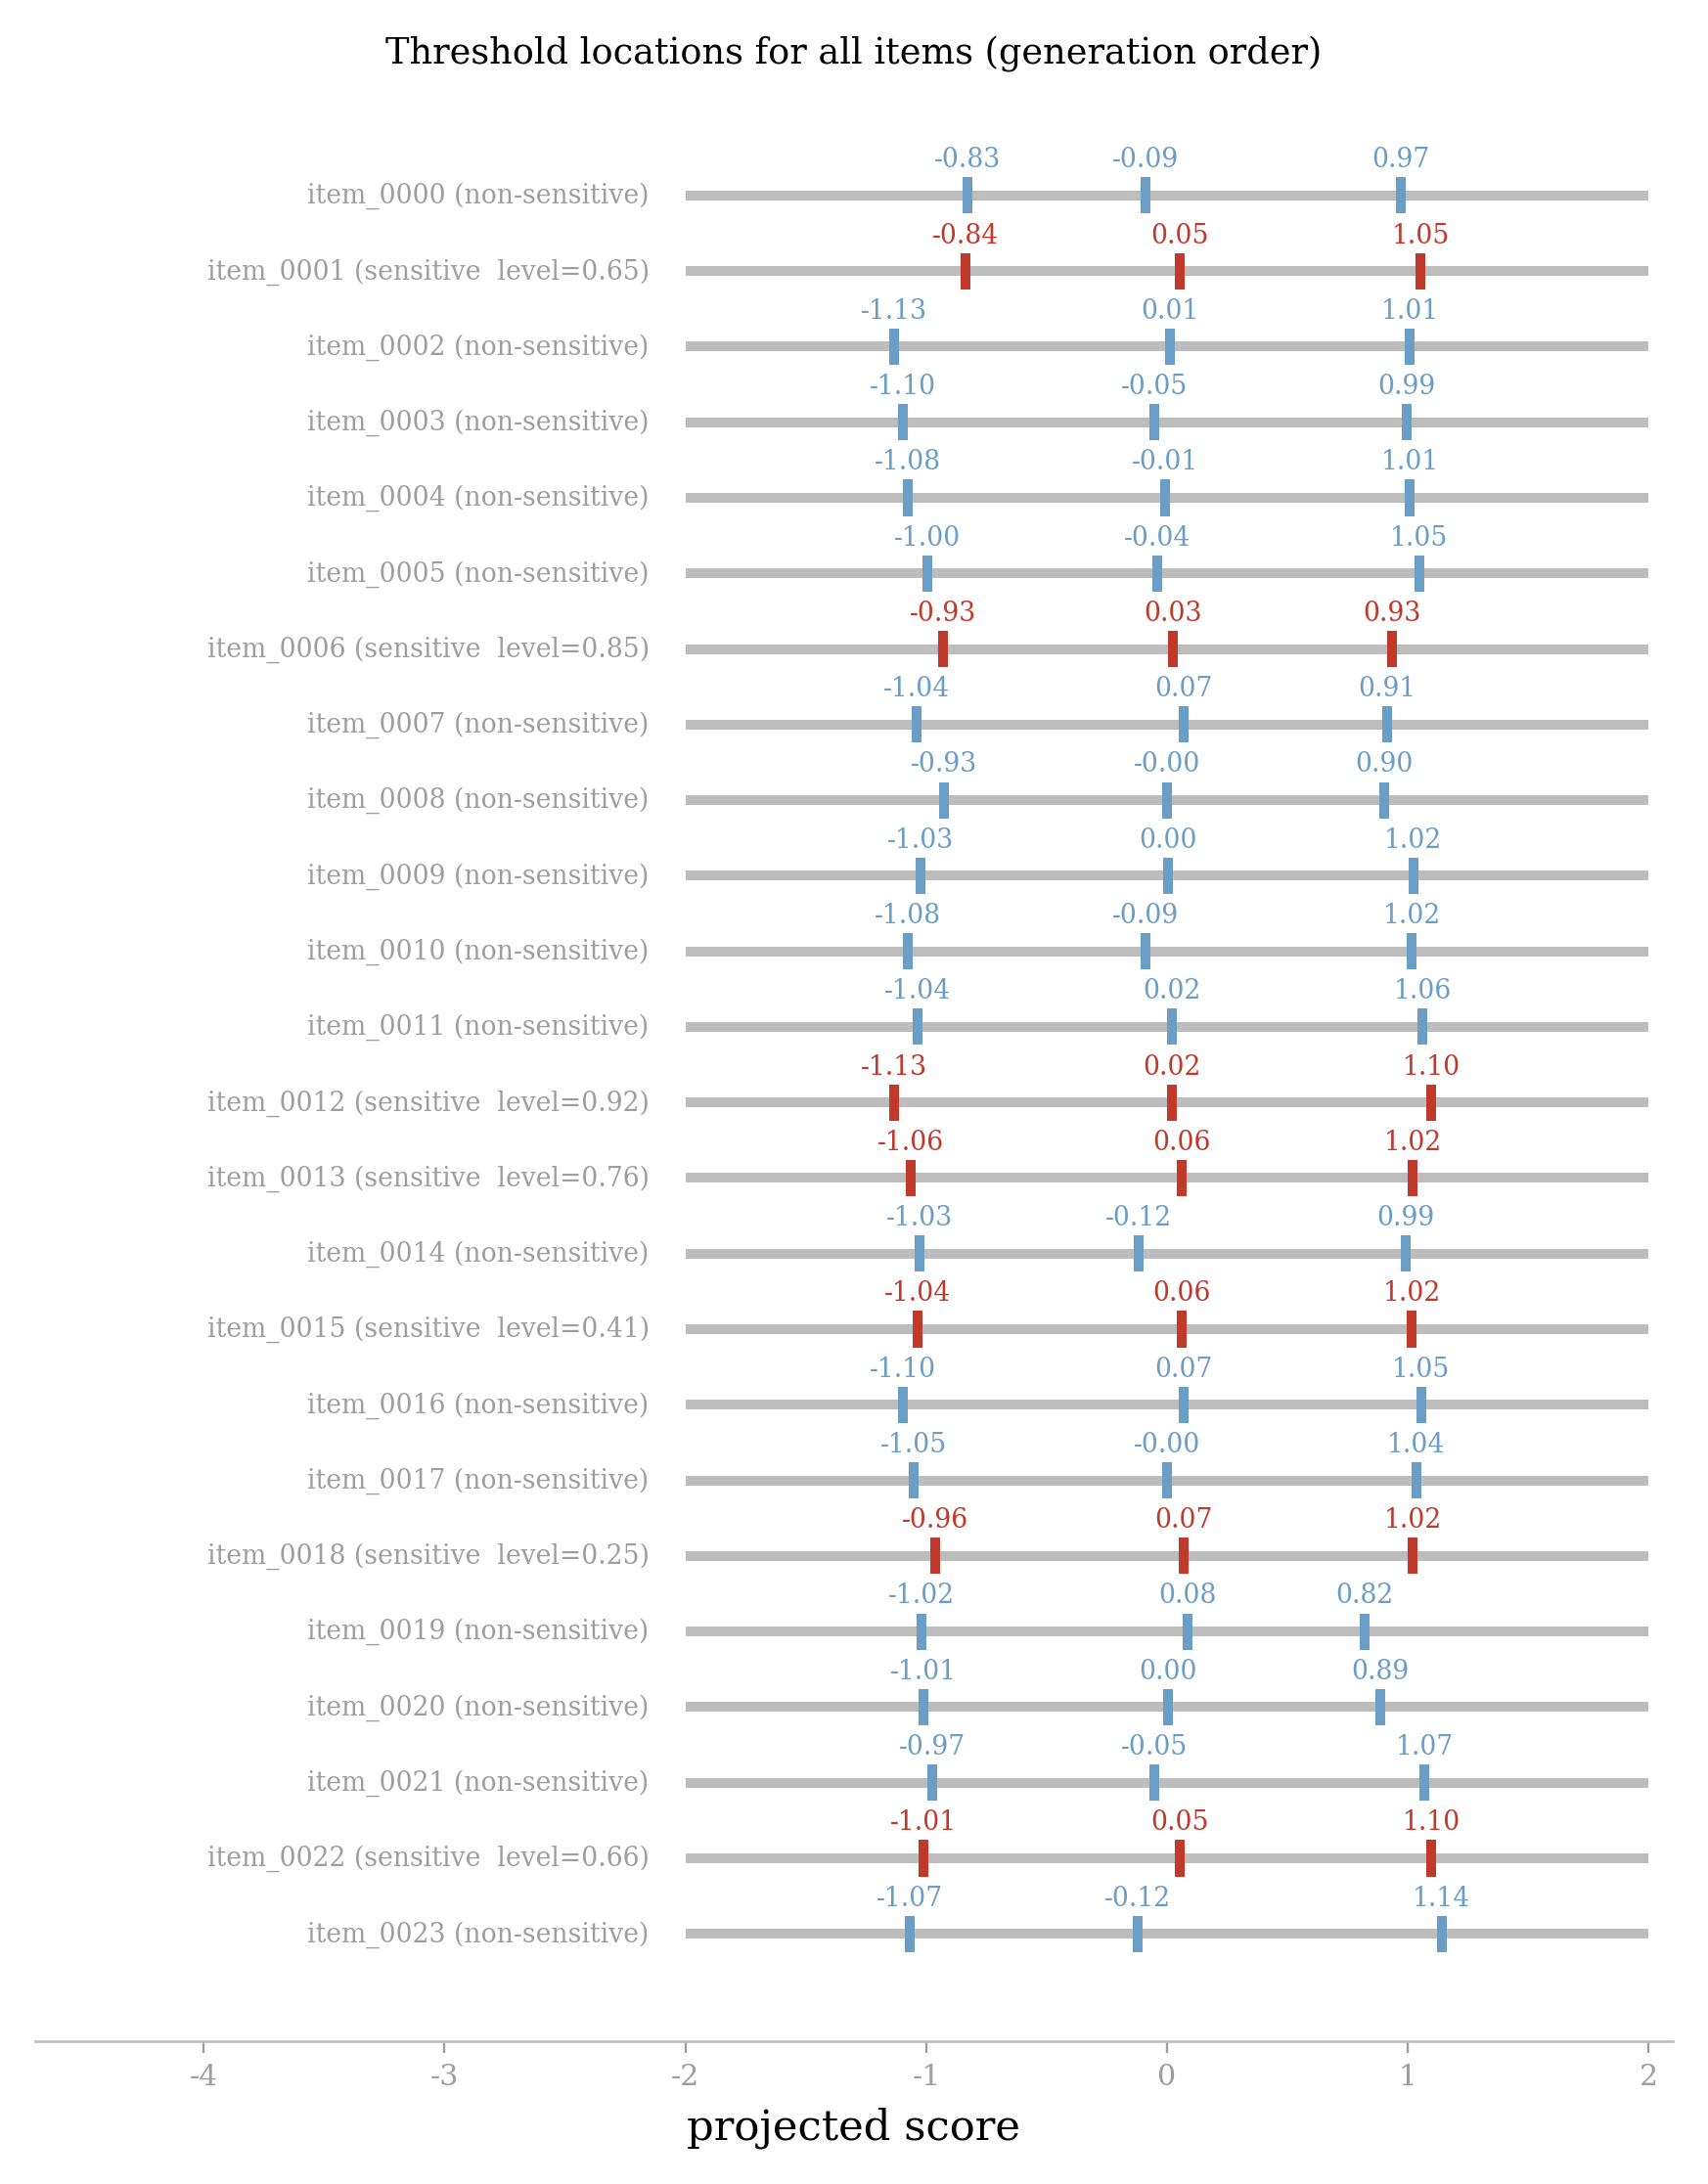

In [7]:
items_to_show = list(bank)  # preserves item generation order

x_min, x_max = -2.0, 2.0
n_rows = len(items_to_show)
fig, ax = plt.subplots(figsize=(9, max(2.8, 0.45 * n_rows)))

for row, item in enumerate(items_to_show):
    y = n_rows - row
    color = colors[item.is_sensitive]
    ax.hlines(y, x_min, x_max, color=PALETTE["rule"], linewidth=3)
    for threshold in item.thresholds:
        ax.vlines(threshold, y - 0.24, y + 0.24, color=color, linewidth=3)
        ax.text(
            threshold, y + 0.30, f"{threshold:.2f}",
            ha="center", va="bottom", color=color, fontsize=8,
        )
    level_str = f"  level={item.sensitivity_level:.2f}" if item.is_sensitive else ""
    ax.text(
        x_min - 0.15, y,
        f"{item.item_id} ({labels[item.is_sensitive]}{level_str})",
        ha="right", va="center", fontsize=8, color=PALETTE["mist"],
    )

ax.set_yticks([])
ax.set_xlabel("projected score")
ax.set_title("Threshold locations for all items (generation order)")
ax.set_xlim(x_min - 2.7, x_max + 0.1)
style_ax(ax, despine_sides=("left", "right", "top"))
plt.show()